# GIS Raster Pipeline — applied to real San Francisco data

The executable companion to [`gis-pipeline-raster.md`](gis-pipeline-raster.md). Same five stages
(**ingest → clean → store → analyze → output**), but driven end-to-end by **real, public datasets**:

| Role | Dataset | Source |
|------|---------|--------|
| **Raster** | Copernicus GLO-30 DEM (elevation, 30 m) | AWS Open Data `copernicus-dem-30m` (a COG) |
| **Zones (vector)** | San Francisco neighborhoods (37 polygons) | `codeforamerica/click_that_hood` GeoJSON |

**The question we answer:** *mean elevation per SF neighborhood* — the raster cousin of the vector
guide's "stations per neighborhood" spatial join. SF is hilly, so the result is physically
meaningful (Twin Peaks high, the waterfront low).

> Four places where **real data departs from the textbook** are flagged inline as **⚠️ Real-data wrinkle**.
> Noticing them *is* the skill; the tidy guide can't show them.

## Cell 0 — Setup

Imports, output folders, and a **cached download helper** — it skips files that already exist, which
keeps `data/raw/` *sacred* (downloaded once, never re-fetched) and makes the whole notebook
re-runnable, the first cross-cutting principle from the guide.

In [1]:
# rasterstats is the only piece of the geo stack not always preinstalled
import importlib, subprocess, sys
if importlib.util.find_spec("rasterstats") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rasterstats"], check=True)

import urllib.request
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
from rasterio.enums import Resampling
from rasterstats import zonal_stats

RAW = Path("data/raw"); PROC = Path("data/processed")
RAW.mkdir(parents=True, exist_ok=True); PROC.mkdir(parents=True, exist_ok=True)

def download(url: str, path: Path) -> Path:
    """Fetch `url` to `path` once; skip if already present (raw data is sacred + re-runnable)."""
    if path.exists():
        print(f"cached  {path}  ({path.stat().st_size/1e6:.1f} MB)")
    else:
        print(f"downloading {url.split('/')[-1]} ...")
        urllib.request.urlretrieve(url, path)
        print(f"saved   {path}  ({path.stat().st_size/1e6:.1f} MB)")
    return path

DEM_URL = ("https://copernicus-dem-30m.s3.amazonaws.com/"
           "Copernicus_DSM_COG_10_N37_00_W123_00_DEM/"
           "Copernicus_DSM_COG_10_N37_00_W123_00_DEM.tif")
ZONES_URL = ("https://raw.githubusercontent.com/codeforamerica/click_that_hood/"
             "master/public/data/san-francisco.geojson")
print("setup OK")

setup OK


## Stage 1 — Ingest

A GeoTIFF is **self-describing**: `open_rasterio` reads its CRS, transform, and (declared) NoData for
us — no coordinates to build by hand. `masked=True` turns any declared NoData straight into `NaN`.
Then we **inspect before trusting**: CRS / transform / nodata / shape, and a plot.

In [ ]:
dem_path = download(DEM_URL, RAW / "sf_copernicus_dem.tif")
print("DEM URL:", DEM_URL)

dem_raw = rioxarray.open_rasterio(dem_path, masked=True).squeeze()  # squeeze the single band

print("CRS      :", dem_raw.rio.crs)
print("shape    :", dem_raw.shape, "(rows, cols)")
print("transform:", dem_raw.rio.transform())
print("nodata   :", dem_raw.rio.nodata)
print("value rng: %.1f .. %.1f m" % (float(dem_raw.min()), float(dem_raw.max())))

cached  data\raw\sf_copernicus_dem.tif  (20.1 MB)
DEM URL: https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N37_00_W123_00_DEM/Copernicus_DSM_COG_10_N37_00_W123_00_DEM.tif
CRS      : EPSG:4326
shape    : (3600, 3600) (rows, cols)
transform: | 0.00, 0.00,-123.00|
| 0.00,-0.00, 38.00|
| 0.00, 0.00, 1.00|
nodata   : None
value rng: -79.1 .. 1006.7 m


> ### ⚠️ Real-data wrinkle #1 — `nodata` is `None`
>
> The textbook says "mask NoData first." But this DEM declares **no** NoData sentinel at all — every
> cell is a real measurement (the value range even dips slightly *below* 0 m near the coast). There's
> no `-9999` flag to strip, so the masking step (Stage 2a) is a **no-op here**. That's not a bug; it's
> what real data often looks like. **Inspecting `.rio.nodata` is exactly how you discover this** —
> which is why "inspect before trusting" is a rule, not a nicety. We keep the masking *pattern* below
> so the same code is correct for the next dataset that *does* carry a sentinel.

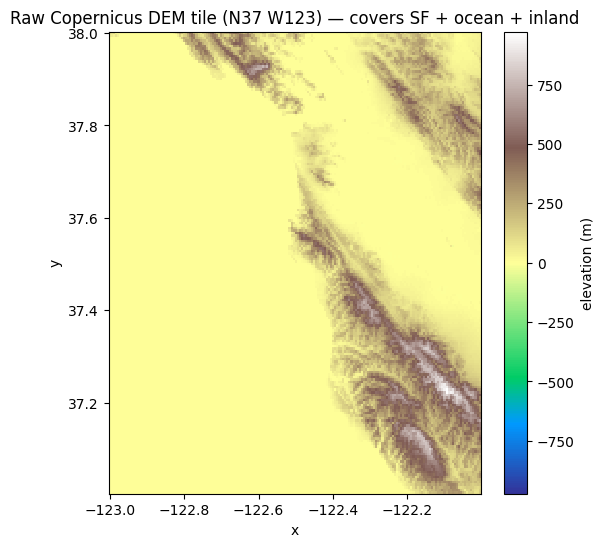

In [3]:
# Quick look at the full 1°×1° tile (downsampled). The low/near-zero band on the west IS the Pacific.
fig, ax = plt.subplots(figsize=(6, 6))
dem_raw[::20, ::20].plot(ax=ax, cmap="terrain", cbar_kwargs={"label": "elevation (m)"})
ax.set_title("Raw Copernicus DEM tile (N37 W123) — covers SF + ocean + inland")
plt.show()

## Stage 2 — Clean / Transform

Order: **(a) mask NoData → (b) reproject (= resample) → (c) clip to the area we care about.**

First load the **zones** (neighborhoods) — they decide the target CRS and the clip box.
We derive the projected CRS with `estimate_utm_crs()` exactly like the vector guide, rather than
hardcoding a zone.

In [4]:
zones = gpd.read_file(ZONES_URL)
zones = zones[["name", "geometry"]]                 # keep only what we need
zones["geometry"] = zones.make_valid()              # repair any invalid polygon rings
print(f"{len(zones)} neighborhoods | source CRS: {zones.crs}")

target = zones.estimate_utm_crs()                   # SF → UTM zone 10N
print("estimated target CRS:", target.to_epsg(), target.name)
assert target.to_epsg() == 32610, "expected UTM 10N for San Francisco"
zones = zones.to_crs(target)                        # convert (recomputes coords → meters)

37 neighborhoods | source CRS: EPSG:4326
estimated target CRS: 32610 WGS 84 / UTM zone 10N


> ### ⚠️ Real-data wrinkle #2 — it's UTM **10N (EPSG:32610)**, not the guide's `32618`
>
> The markdown guide hardcodes `EPSG:32618` — that's UTM zone **18N**, correct for *New York*, wrong
> for San Francisco. Hardcoding a CRS is how silent location bugs creep in. `estimate_utm_crs()`
> picks the right zone from the data's own footprint, so the same code is correct in any city.

In [5]:
# 2a. mask NoData (no-op here since nodata is None — see wrinkle #1 — but correct in general)
dem = dem_raw if dem_raw.rio.nodata is None else dem_raw.where(dem_raw != dem_raw.rio.nodata)

# 2b. reproject to the SAME projected CRS as the zones. Reprojection RESAMPLES:
#     elevation is CONTINUOUS → bilinear (use Resampling.nearest for categorical class rasters).
dem = dem.rio.reproject(target, resampling=Resampling.bilinear)

# 2c. clip to the neighborhoods' bounding box — process SF, not the whole 1°×1° tile (wrinkle #3)
dem = dem.rio.clip_box(*zones.total_bounds)

print("reprojected CRS:", dem.rio.crs.to_epsg())
print("clipped shape  :", dem.shape, "(was", dem_raw.shape, ")")
print("pixel size     : %.1f m" % abs(dem.rio.resolution()[0]))
assert dem.rio.crs == zones.crs, "raster and zones must share a CRS before zonal stats"

reprojected CRS: 32610
clipped shape  : (502, 502) (was (3600, 3600) )
pixel size     : 27.9 m


> ### ⚠️ Real-data wrinkle #3 — the tile is bigger than the city
>
> Copernicus ships 1°×1° tiles; SF occupies a small corner. `clip_box` to the zones' bounds means we
> store and analyze only the relevant pixels — a realistic, near-free win in I/O and memory.
>
> **`.crs =` (declare, moves nothing) vs `.to_crs()` / `reproject()` (convert, recomputes).** And for
> rasters, convert also **resamples** — `bilinear` for continuous data, `nearest` for categorical.

## Stage 3 — Store (Cloud-Optimized GeoTIFF)

Write the cleaned raster as a **COG** — internal tiling + overview pyramids are the raster analogue
of a spatial index: a reader can fetch one tile or a coarse zoom without scanning the whole file.
Output goes to `data/processed/`, leaving `data/raw/` untouched.

> ### ⚠️ Real-data wrinkle #4 — overviews only appear above one block
>
> A COG's overviews (downsampled pyramids) are its headline feature, but GDAL only generates them
> when the image is **larger than one tile/block**. Our clipped SF raster is ~502 px — *smaller* than
> the default 512 px block — so with defaults it gets **zero** overviews. Setting `blocksize=256`
> makes the image span multiple blocks, so a pyramid level is written. On a full-size raster the
> default is fine; the lesson is that "write a COG" doesn't guarantee overviews — **verify, don't assume.**

In [6]:
cog_path = PROC / "sf_dem_utm.tif"
# blocksize=256: our clipped SF raster (~502 px) is smaller than the COG driver's default 512 px
# block, so it would get NO overviews at all. A smaller block lets the pyramid form (wrinkle #4).
dem.rio.to_raster(cog_path, driver="COG", compress="deflate", blocksize=256)

# prove tiling + overviews were actually written
import rasterio
with rasterio.open(cog_path) as ds:
    print("wrote COG  :", cog_path, f"({cog_path.stat().st_size/1e6:.1f} MB)")
    print("tiled      :", ds.profile.get("tiled"), "| block:", ds.profile.get("blockxsize"))
    print("overviews  :", ds.overviews(1), "(downsample factors baked in)")

wrote COG  : data\processed\sf_dem_utm.tif (0.7 MB)
tiled      : True | block: 256
overviews  : [2] (downsample factors baked in)


## Stage 4 — Analyze (zonal statistics)

The headline. **Zonal statistics is the structural twin of the vector spatial join + groupby:**
instead of *counting points inside each polygon*, we *summarize the raster cells inside each polygon*.
This is where **raster meets vector** — the neighborhoods are the zones.

Both layers are already in the same CRS (we asserted it in Stage 2). If the stats came back all-null,
the first suspect would be a CRS mismatch.

In [7]:
stats = zonal_stats(zones, str(cog_path), stats=["mean", "min", "max"], nodata=dem.rio.nodata)
zones["mean_elev"] = [s["mean"] for s in stats]
zones["min_elev"]  = [s["min"]  for s in stats]
zones["max_elev"]  = [s["max"]  for s in stats]

assert zones["mean_elev"].notna().any(), "all-null zonal stats → suspect a CRS mismatch first"
ranked = zones.sort_values("mean_elev", ascending=False)
print("Highest neighborhoods (mean elevation, m):")
print(ranked[["name", "mean_elev", "max_elev"]].head(5).to_string(index=False))
print("\nLowest neighborhoods:")
print(ranked[["name", "mean_elev", "max_elev"]].tail(5).to_string(index=False))

Highest neighborhoods (mean elevation, m):


              name  mean_elev   max_elev
        Twin Peaks 193.446737 273.053436
   Diamond Heights 149.561443 202.021255
West of Twin Peaks 149.249802 277.282074
      Inner Sunset 140.520674 267.196503
    Haight Ashbury  99.520186 191.300217

Lowest neighborhoods:
               name  mean_elev   max_elev
             Marina  17.657900  71.350594
            Bayview  15.816992 142.068085
Treasure Island/YBI  14.164237 105.912270
 Financial District  13.726448  55.912025
    South of Market  10.024501  39.211246


**Sanity check:** the ranking should be physically plausible — hilltop neighborhoods (Twin Peaks,
Diamond Heights, Clarendon Heights) near the top, waterfront/landfill (the Marina, Mission Bay,
Treasure Island, SoMa) near the bottom. If the numbers were nonsense or all-null, **suspect CRS first.**

## Stage 5 — Output (three forms, three audiences)

- **PNG** choropleth — for humans (`viridis`: perceptually uniform + colorblind-safe).
- **GeoPackage** — the per-zone stats table for GIS tools / apps.
- **COG** — already written in Stage 3, for tile servers.

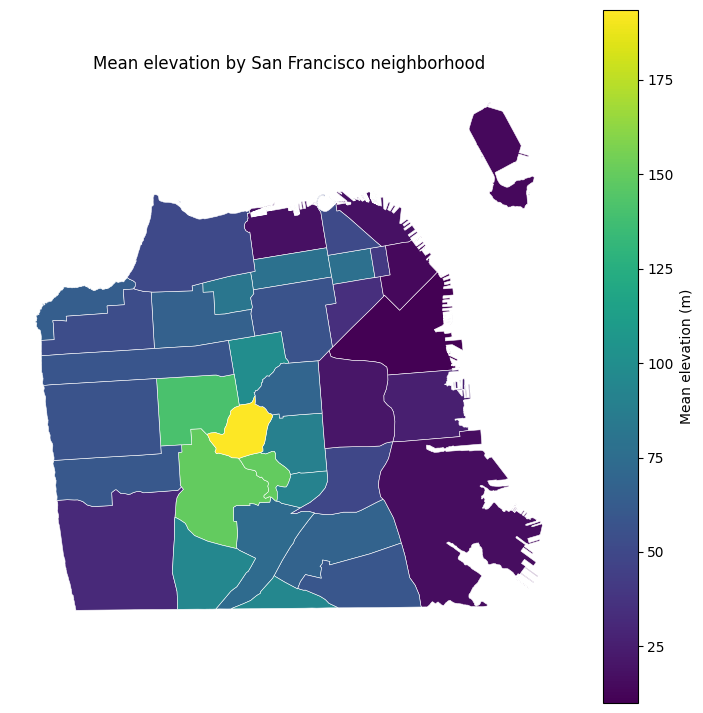

outputs:
  PNG  → data\processed\sf_elevation_map.png
  GPKG → data\processed\sf_neighborhood_elevation.gpkg
  COG  → data\processed\sf_dem_utm.tif (Stage 3)


In [8]:
fig, ax = plt.subplots(figsize=(9, 9))
zones.plot(column="mean_elev", cmap="viridis", legend=True,
           legend_kwds={"label": "Mean elevation (m)"},
           edgecolor="white", linewidth=0.4, ax=ax)
ax.set_title("Mean elevation by San Francisco neighborhood"); ax.set_axis_off()
png_path = PROC / "sf_elevation_map.png"
fig.savefig(png_path, dpi=200, bbox_inches="tight")
plt.show()

gpkg_path = PROC / "sf_neighborhood_elevation.gpkg"
zones.to_file(gpkg_path, driver="GPKG")
print("outputs:")
print("  PNG  →", png_path)
print("  GPKG →", gpkg_path)
print("  COG  →", cog_path, "(Stage 3)")

## Tying it together — one re-runnable pipeline

The five stages as isolated functions, mirroring the guide's "one re-runnable pipeline" section.
Each is testable on its own and re-runnable without touching the others.

In [9]:
def ingest():
    p = download(DEM_URL, RAW / "sf_copernicus_dem.tif")
    return rioxarray.open_rasterio(p, masked=True).squeeze()

def clean(dem_raw, zones):
    dem = dem_raw if dem_raw.rio.nodata is None else dem_raw.where(dem_raw != dem_raw.rio.nodata)
    dem = dem.rio.reproject(zones.crs, resampling=Resampling.bilinear)
    return dem.rio.clip_box(*zones.total_bounds)

def store(dem, path=PROC / "sf_dem_utm.tif"):
    dem.rio.to_raster(path, driver="COG", compress="deflate", blocksize=256)  # blocksize → overviews
    return path

def analyze(cog_path, zones, nodata):
    s = zonal_stats(zones, str(cog_path), stats=["mean", "min", "max"], nodata=nodata)
    out = zones.copy()
    out["mean_elev"] = [r["mean"] for r in s]
    return out

def output(result, png=PROC / "sf_elevation_map.png", gpkg=PROC / "sf_neighborhood_elevation.gpkg"):
    result.to_file(gpkg, driver="GPKG")
    return gpkg

# zones prepared once (they define the CRS + clip box for the raster)
z = gpd.read_file(ZONES_URL)[["name", "geometry"]]
z["geometry"] = z.make_valid()
z = z.to_crs(z.estimate_utm_crs())

raw = ingest()
cln = clean(raw, z)
cog = store(cln)
res = analyze(cog, z, cln.rio.nodata)
output(res)
print("pipeline complete —", len(res), "neighborhoods, mean elev range",
      f"{res['mean_elev'].min():.1f}..{res['mean_elev'].max():.1f} m")

cached  data\raw\sf_copernicus_dem.tif  (20.1 MB)


pipeline complete — 37 neighborhoods, mean elev range 10.0..193.4 m


## What this run demonstrated — back to the guide

**Hand-off contract**, satisfied at each stage:
1. **Ingest** → raster loaded with CRS, transform, and (the lack of a) NoData known.
2. **Clean** → same projected CRS as the zones (UTM 10N, *derived* not hardcoded), resampled with a
   type-appropriate method (`bilinear`), clipped to the area of interest.
3. **Store** → a COG with tiling + overviews (overviews needed a tuned block size — see wrinkle #4).
4. **Analyze** → zonal stats, no all-null, physically plausible ranking.
5. **Output** → PNG (humans) + GPKG (tools) + COG (tile servers).

**The four real-data wrinkles** — none of which the tidy markdown guide shows:
1. **`nodata` was `None`** — the masking step was a no-op; no sentinel to strip. *Inspect, don't assume.*
2. **UTM zone was 10N, not the guide's 18N** — `estimate_utm_crs()` beats a hardcoded EPSG.
3. **The tile was bigger than the city** — `clip_box` keeps the pipeline lean.
4. **A small COG got no overviews by default** — tune `blocksize`, and *verify* the pyramid was written.

> **The one idea to keep:** raster reprojection *resamples* — the method must match whether the data
> is continuous (`bilinear`) or categorical (`nearest`). And when a zonal join comes back empty,
> **suspect CRS first.**